# Name : Motuma Abera
#ID : GSE0176/18
# Big Data Analytics and Visualization: NLP Lab Exercises

This notebook completes two Natural Language Processing lab exercises using Python.

- **LAB_1:** Text data processing, visualization, word frequencies, word cloud, and TF-IDF.
- **LAB_2:** Hotel review sentiment analysis using TF-IDF and Multinomial Naive Bayes.

The notebook also exports the required CSV files and saves all generated plots inside the `outputs` folder.

## Setup

The following libraries are used throughout the notebook: `pandas`, `matplotlib`, `seaborn`, `nltk`, `wordcloud`, and `scikit-learn`.

If NLTK raises a `punkt_tab` error on a new machine, the downloads below fix it by installing the tokenizer and stopword resources.

In [ ]:
# Uncomment the line below if the required libraries are not installed.
# %pip install pandas matplotlib seaborn nltk wordcloud scikit-learn

from collections import Counter
import string
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

sns.set_theme(style="whitegrid")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
english_stopwords = set(stopwords.words("english"))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\coop\AppData\Roaming\nltk_data...


[nltk_data]   Unzipping tokenizers\punkt.zip.


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\coop\AppData\Roaming\nltk_data...


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\coop\AppData\Roaming\nltk_data...


[nltk_data]   Unzipping corpora\stopwords.zip.


# LAB_1: Text Data Processing and Visualization

LAB_1 uses a small educational technology text dataset to demonstrate text cleaning, tokenization, frequency analysis, visualization, and TF-IDF representation.

## 1. Load Text Data

The five given sentences are loaded into a pandas DataFrame. This makes the text easier to inspect, clean, transform, and compare.

In [ ]:
lab1_texts = [
    "Technology is transforming education",
    "Big data enables better decision making",
    "Machine learning is powerful",
    "AI and data science are related fields",
    "Education is evolving with technology",
]

lab1_df = pd.DataFrame({"Text": lab1_texts})
lab1_df.head()

,Text
0,Technology is transforming education
1,Big data enables better decision making
2,Machine learning is powerful
3,AI and data science are related fields
4,Education is evolving with technology


## 2. Preprocess Text

The preprocessing function converts text to lowercase, removes punctuation, tokenizes with NLTK, removes English stopwords, and keeps alphabetic words only.

In [ ]:
def preprocess_text(text, extra_stopwords=None):
    """Clean a text string and return useful word tokens."""
    extra_stopwords = set(extra_stopwords or [])
    all_stopwords = english_stopwords.union(extra_stopwords)
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    cleaned_tokens = [
        token for token in tokens
        if token.isalpha() and token not in all_stopwords
    ]
    return cleaned_tokens


lab1_df["Tokens"] = lab1_df["Text"].apply(preprocess_text)
lab1_df["Cleaned_Text"] = lab1_df["Tokens"].apply(lambda tokens: " ".join(tokens))
lab1_df

,Text,Tokens,Cleaned_Text
0,Technology is transforming education,"[technology, transforming, education]",technology transforming education
1,Big data enables better decision making,"[big, data, enables, better, decision, making]",big data enables better decision making
2,Machine learning is powerful,"[machine, learning, powerful]",machine learning powerful
3,AI and data science are related fields,"[ai, data, science, related, fields]",ai data science related fields
4,Education is evolving with technology,"[education, evolving, technology]",education evolving technology


## 3. Word Frequency Analysis

The `Counter` class is used to count how often each cleaned word appears in LAB_1.

In [ ]:
lab1_all_tokens = [token for tokens in lab1_df["Tokens"] for token in tokens]
lab1_word_freq = Counter(lab1_all_tokens)
lab1_word_freq_df = (
    pd.DataFrame(lab1_word_freq.items(), columns=["word", "frequency"])
    .sort_values(["frequency", "word"], ascending=[False, True])
    .reset_index(drop=True)
)

lab1_word_freq_df.to_csv("word_frequency_lab1.csv", index=False)
lab1_word_freq_df

,word,frequency
0,data,2
1,education,2
2,technology,2
3,ai,1
4,better,1
5,big,1
6,decision,1
7,enables,1
8,evolving,1
9,fields,1


## 4. Bar Chart of Top 5 Frequent Words

The chart shows the most repeated cleaned words in the original LAB_1 dataset.

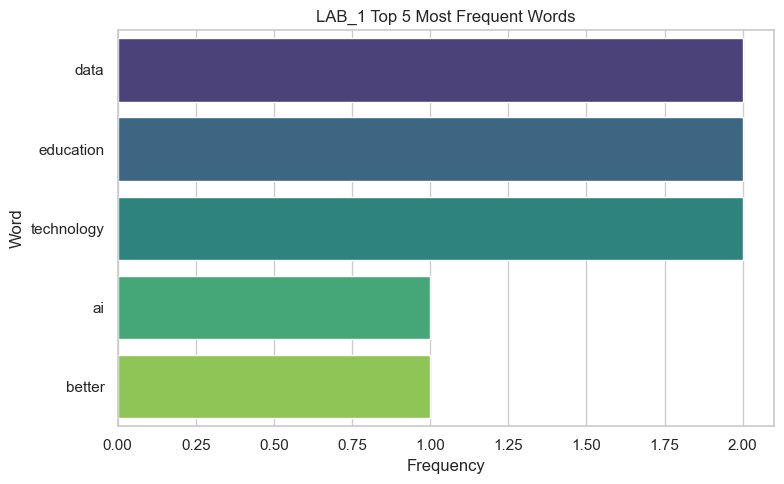

In [ ]:
top5_lab1 = lab1_word_freq_df.head(5)

plt.figure(figsize=(8, 5))
sns.barplot(data=top5_lab1, x="frequency", y="word", hue="word", palette="viridis", legend=False)
plt.title("LAB_1 Top 5 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_top5_words.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The most frequent words reflect the dataset themes: education, technology, data, and machine learning. Repeated words such as `education`, `technology`, and `data` indicate the main topics across the short corpus.

## 5. Word Cloud

The word cloud provides a visual summary where larger words occur more frequently.

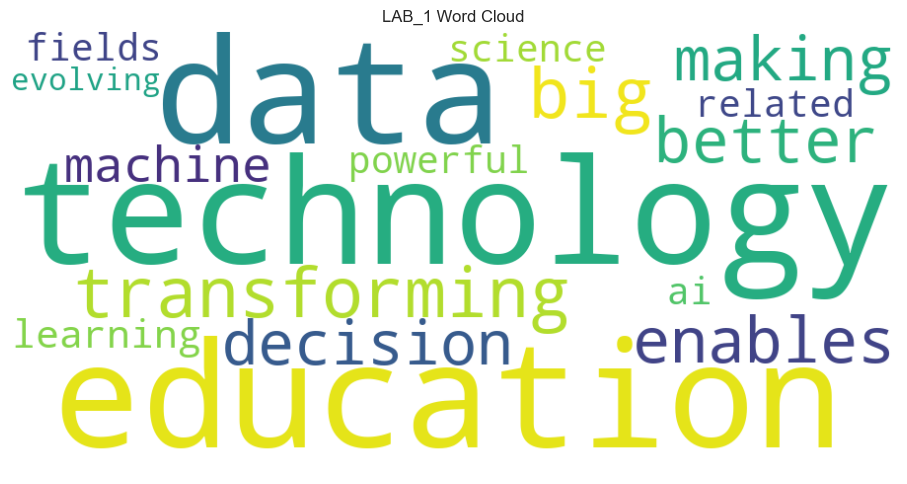

In [ ]:
lab1_wordcloud = WordCloud(width=900, height=450, background_color="white", colormap="viridis").generate(
    " ".join(lab1_all_tokens)
)

plt.figure(figsize=(10, 5))
plt.imshow(lab1_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("LAB_1 Word Cloud")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The word cloud emphasizes the same dominant vocabulary as the frequency table. It is useful for quickly identifying central ideas in the text collection.

## 6. Word Length Distribution

Word length distribution helps describe the structure of the cleaned vocabulary.

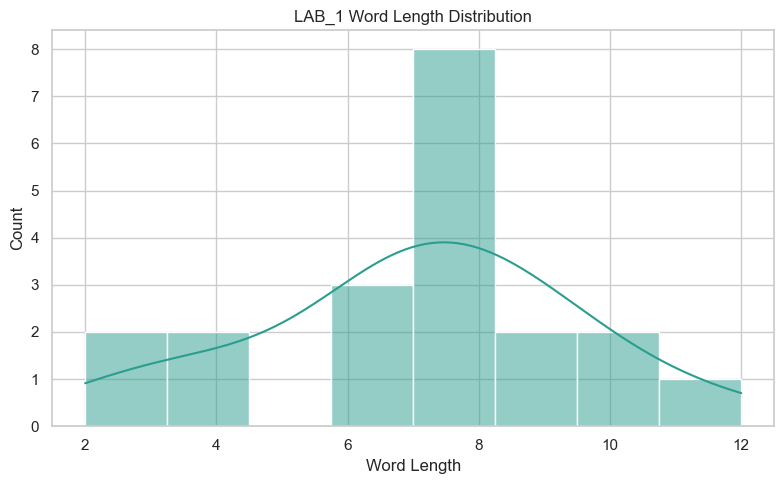

In [ ]:
lab1_word_lengths = pd.DataFrame({"word_length": [len(token) for token in lab1_all_tokens]})

plt.figure(figsize=(8, 5))
sns.histplot(data=lab1_word_lengths, x="word_length", bins=8, kde=True, color="#2a9d8f")
plt.title("LAB_1 Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_word_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Most words have medium length, which is expected for topic-specific terms such as `technology`, `education`, `machine`, and `learning`.

## 7. TF-IDF Vectorization

TF-IDF converts cleaned text into numerical features. Words that are common in a document but less common across all documents receive stronger weights.

In [ ]:
tfidf_vectorizer_lab1 = TfidfVectorizer()
lab1_tfidf_matrix = tfidf_vectorizer_lab1.fit_transform(lab1_df["Cleaned_Text"])
lab1_feature_names = tfidf_vectorizer_lab1.get_feature_names_out()
lab1_tfidf_df = pd.DataFrame(lab1_tfidf_matrix.toarray(), columns=lab1_feature_names)

print("Feature names:")
print(lab1_feature_names)
lab1_tfidf_df

Feature names:
['ai' 'better' 'big' 'data' 'decision' 'education' 'enables' 'evolving'
 'fields' 'learning' 'machine' 'making' 'powerful' 'related' 'science'
 'technology' 'transforming']


,ai,better,big,data,decision,education,enables,evolving,fields,learning,machine,making,powerful,related,science,technology,transforming
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.531772,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.531772,0.659118
1,0.000000,0.420669,0.420669,0.339393,0.420669,0.000000,0.420669,0.000000,0.000000,0.00000,0.00000,0.420669,0.00000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.57735,0.57735,0.000000,0.57735,0.000000,0.000000,0.000000,0.000000
3,0.463693,0.000000,0.000000,0.374105,0.000000,0.000000,0.000000,0.000000,0.463693,0.00000,0.00000,0.000000,0.00000,0.463693,0.463693,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.531772,0.000000,0.659118,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.531772,0.000000


## 8. Add Extra Sentences and Repeat Frequency Analysis

More sentences are added to see how the frequency table and word cloud change when the corpus grows.

In [ ]:
extra_lab1_texts = [
    "Data analytics improves education outcomes",
    "Technology and AI support smarter decision making",
    "Learning data helps educators understand student progress",
]

lab1_extended_df = pd.DataFrame({"Text": lab1_texts + extra_lab1_texts})
lab1_extended_df["Tokens"] = lab1_extended_df["Text"].apply(preprocess_text)
lab1_extended_df["Cleaned_Text"] = lab1_extended_df["Tokens"].apply(lambda tokens: " ".join(tokens))

lab1_extended_tokens = [token for tokens in lab1_extended_df["Tokens"] for token in tokens]
lab1_extended_freq_df = (
    pd.DataFrame(Counter(lab1_extended_tokens).items(), columns=["word", "frequency"])
    .sort_values(["frequency", "word"], ascending=[False, True])
    .reset_index(drop=True)
)

lab1_extended_freq_df.head(10)

,word,frequency
0,data,4
1,education,3
2,technology,3
3,ai,2
4,decision,2
5,learning,2
6,making,2
7,analytics,1
8,better,1
9,big,1


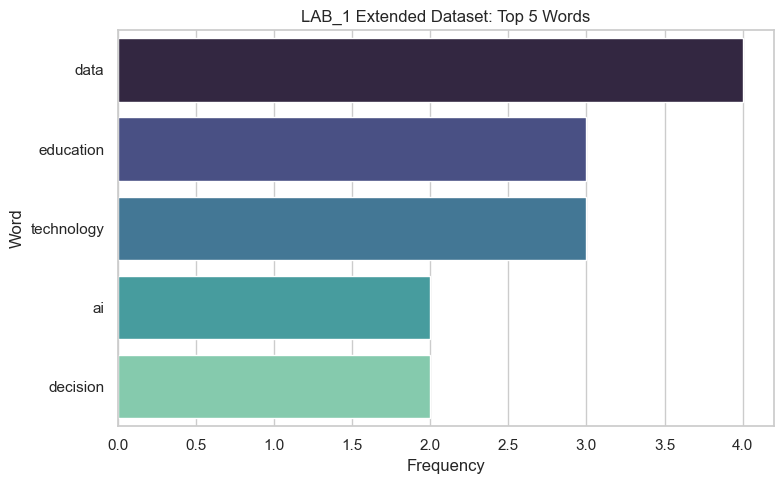

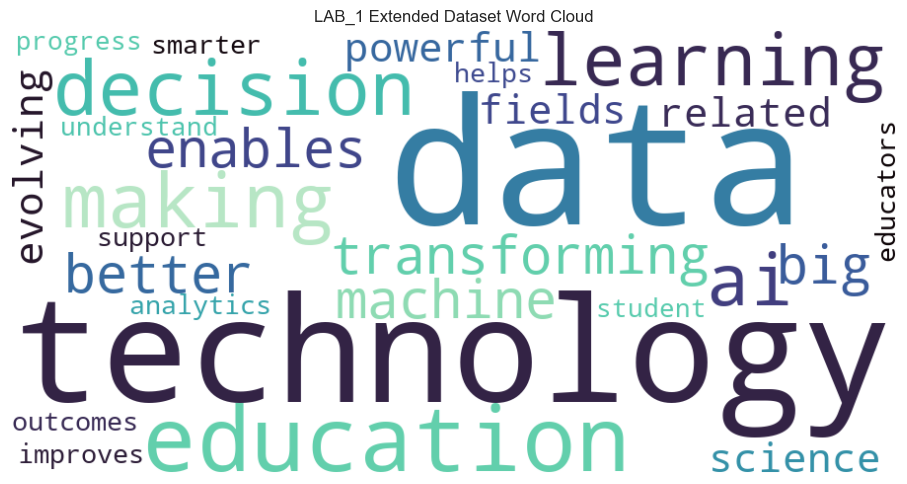

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=lab1_extended_freq_df.head(5),
    x="frequency",
    y="word",
    hue="word",
    palette="mako",
    legend=False,
)
plt.title("LAB_1 Extended Dataset: Top 5 Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_extended_top5_words.png", dpi=150, bbox_inches="tight")
plt.show()

extended_wordcloud = WordCloud(width=900, height=450, background_color="white", colormap="mako").generate(
    " ".join(lab1_extended_tokens)
)
plt.figure(figsize=(10, 5))
plt.imshow(extended_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("LAB_1 Extended Dataset Word Cloud")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_extended_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** After adding more sentences, `data`, `education`, `technology`, and learning-related terms become more prominent. This shows how corpus expansion changes word importance.

## 9. Manual Extra Stopword Removal

The words `data`, `fields`, and `related` are removed manually because they may be too broad or less useful for interpretation in this small example.

In [ ]:
manual_stopwords = {"data", "fields", "related"}
lab1_df["Tokens_Manual_Stopwords"] = lab1_df["Text"].apply(lambda text: preprocess_text(text, manual_stopwords))
lab1_df["Cleaned_Text_Manual_Stopwords"] = lab1_df["Tokens_Manual_Stopwords"].apply(lambda tokens: " ".join(tokens))
lab1_df[["Text", "Cleaned_Text", "Cleaned_Text_Manual_Stopwords"]]

,Text,Cleaned_Text,Cleaned_Text_Manual_Stopwords
0,Technology is transforming education,technology transforming education,technology transforming education
1,Big data enables better decision making,big data enables better decision making,big enables better decision making
2,Machine learning is powerful,machine learning powerful,machine learning powerful
3,AI and data science are related fields,ai data science related fields,ai science
4,Education is evolving with technology,education evolving technology,education evolving technology


## 10. Raw Text vs Cleaned Text

This comparison table shows the effect of preprocessing on each sentence.

In [ ]:
raw_vs_cleaned_lab1 = lab1_df[["Text", "Cleaned_Text"]].rename(
    columns={"Text": "Raw_Text", "Cleaned_Text": "Cleaned_Text"}
)
raw_vs_cleaned_lab1

,Raw_Text,Cleaned_Text
0,Technology is transforming education,technology transforming education
1,Big data enables better decision making,big data enables better decision making
2,Machine learning is powerful,machine learning powerful
3,AI and data science are related fields,ai data science related fields
4,Education is evolving with technology,education evolving technology


## 11. Bigram TF-IDF

Bigram TF-IDF includes both single words and two-word phrases. This can capture phrases such as `machine learning`, `data science`, and `decision making`.

In [ ]:
bigram_vectorizer_lab1 = TfidfVectorizer(ngram_range=(1, 2))
lab1_bigram_matrix = bigram_vectorizer_lab1.fit_transform(lab1_df["Cleaned_Text"])
lab1_bigram_features = bigram_vectorizer_lab1.get_feature_names_out()
lab1_bigram_tfidf_df = pd.DataFrame(lab1_bigram_matrix.toarray(), columns=lab1_bigram_features)

print("Bigram TF-IDF feature names:")
print(lab1_bigram_features)
lab1_bigram_tfidf_df

Bigram TF-IDF feature names:
['ai' 'ai data' 'better' 'better decision' 'big' 'big data' 'data'
 'data enables' 'data science' 'decision' 'decision making' 'education'
 'education evolving' 'enables' 'enables better' 'evolving'
 'evolving technology' 'fields' 'learning' 'learning powerful' 'machine'
 'machine learning' 'making' 'powerful' 'related' 'related fields'
 'science' 'science related' 'technology' 'technology transforming'
 'transforming' 'transforming education']


,ai,ai data,better,better decision,big,big data,data,data enables,data science,decision,...,making,powerful,related,related fields,science,science related,technology,technology transforming,transforming,transforming education
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.388988,0.48214,0.48214,0.48214
1,0.000000,0.000000,0.306413,0.306413,0.306413,0.306413,0.247212,0.306413,0.000000,0.306413,...,0.306413,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.447214,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
3,0.339992,0.339992,0.000000,0.000000,0.000000,0.000000,0.274304,0.000000,0.339992,0.000000,...,0.000000,0.000000,0.339992,0.339992,0.339992,0.339992,0.000000,0.00000,0.00000,0.00000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.388988,0.00000,0.00000,0.00000


# LAB_2: Hotel Review Sentiment Analysis

LAB_2 uses labeled hotel reviews to train a sentiment classifier with TF-IDF features and Multinomial Naive Bayes.

## 1. Load Hotel Review Data

The dataset contains hotel reviews labeled as `positive`, `negative`, or `neutral`.

In [ ]:
hotel_texts = [
    "I had a wonderful stay at the hotel. The staff were very friendly and helpful throughout my visit.",
    "The room was clean and spacious, and the bed was extremely comfortable.",
    "Breakfast service was excellent with a wide variety of delicious food options.",
    "The location is very convenient, especially for travelers near the airport.",
    "Customer service was outstanding, and the staff responded quickly to all my requests.",
    "The check-in process was slow, and I had to wait for a long time at the reception.",
    "The room was not as clean as expected, and the bathroom had some issues.",
    "I was disappointed with the food quality; it did not meet my expectations.",
    "The staff seemed untrained and were not very responsive to customer complaints.",
    "There was too much noise at night, which made it difficult to sleep.",
    "The hotel is located near the airport, which is convenient for transit passengers.",
    "The room size is average, and the facilities are standard.",
    "WiFi service is available throughout the hotel.",
    "The hotel offers transportation services to and from the airport.",
    "The overall experience was okay, nothing particularly impressive or disappointing.",
    "I really enjoyed the hospitality; the staff went above and beyond to make my stay pleasant.",
    "The cleanliness of the hotel was impressive, and everything was well maintained.",
    "Room service was quick and efficient, and the food tasted great.",
    "The hotel environment was calm and relaxing, perfect for business travelers.",
    "The air conditioning system was not working properly during my stay.",
    "Housekeeping was inconsistent, and sometimes the room was not cleaned on time.",
    "The price of the hotel is quite high compared to the services provided.",
    "The hotel provides basic amenities such as towels, toiletries, and bottled water.",
    "The lobby area is large and suitable for meetings and short waiting periods.",
    "Security at the hotel is visible, and guests are checked upon entry.",
]

hotel_labels = [
    "positive", "positive", "positive", "positive", "positive",
    "negative", "negative", "negative", "negative", "negative",
    "neutral", "neutral", "neutral", "neutral", "neutral",
    "positive", "positive", "positive", "positive",
    "negative", "negative", "negative",
    "neutral", "neutral", "neutral",
]

hotel_df = pd.DataFrame({"Text": hotel_texts, "Sentiment": hotel_labels})
hotel_df.head()

,Text,Sentiment
0,I had a wonderful stay at the hotel. The staff...,positive
1,"The room was clean and spacious, and the bed w...",positive
2,Breakfast service was excellent with a wide va...,positive
3,"The location is very convenient, especially fo...",positive
4,"Customer service was outstanding, and the staf...",positive


## 2. Explore Dataset and Sentiment Distribution

The class distribution is checked before modeling to understand how many reviews belong to each sentiment category.

In [ ]:
sentiment_distribution = hotel_df["Sentiment"].value_counts()
sentiment_distribution

Sentiment
positive    9
negative    8
neutral     8
Name: count, dtype: int64

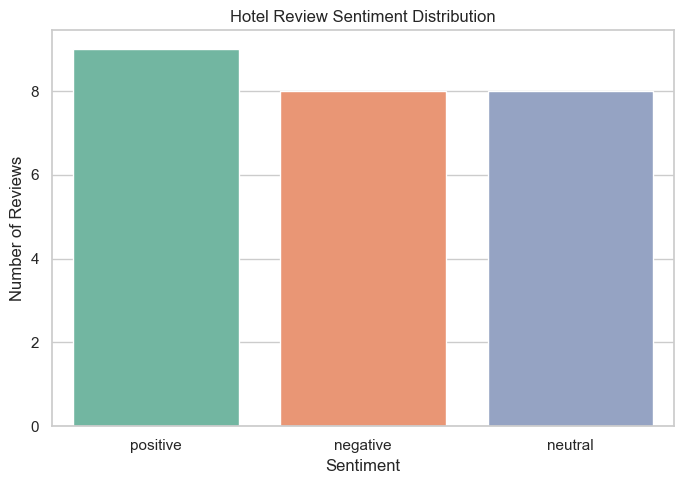

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=hotel_df, x="Sentiment", hue="Sentiment", order=["positive", "negative", "neutral"], palette="Set2", legend=False)
plt.title("Hotel Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab2_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The dataset is almost balanced, with slightly more positive reviews than negative and neutral reviews. A balanced dataset helps the classifier learn all classes more fairly.

## 3. Preprocess Hotel Reviews

Reviews are lowercased, tokenized, stripped of punctuation, filtered to alphabetic words, and cleaned of English stopwords.

In [ ]:
hotel_df["Tokens"] = hotel_df["Text"].apply(preprocess_text)
hotel_df["Cleaned_Text"] = hotel_df["Tokens"].apply(lambda tokens: " ".join(tokens))
hotel_df[["Text", "Sentiment", "Cleaned_Text"]].head()

,Text,Sentiment,Cleaned_Text
0,I had a wonderful stay at the hotel. The staff...,positive,wonderful stay hotel staff friendly helpful th...
1,"The room was clean and spacious, and the bed w...",positive,room clean spacious bed extremely comfortable
2,Breakfast service was excellent with a wide va...,positive,breakfast service excellent wide variety delic...
3,"The location is very convenient, especially fo...",positive,location convenient especially travelers near ...
4,"Customer service was outstanding, and the staf...",positive,customer service outstanding staff responded q...


## 4. TF-IDF Vectorization and Train-Test Split

The cleaned reviews are transformed into TF-IDF features. The data is then split using `test_size=0.2` and `random_state=42`.

In [ ]:
tfidf_vectorizer_lab2 = TfidfVectorizer()
X = tfidf_vectorizer_lab2.fit_transform(hotel_df["Cleaned_Text"])
y = hotel_df["Sentiment"]

X_train, X_test, y_train, y_test, train_index, test_index = train_test_split(
    X,
    y,
    hotel_df.index,
    test_size=0.2,
    random_state=42,
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of TF-IDF features:", X.shape[1])

Training samples: 20
Testing samples: 5
Number of TF-IDF features: 131


## 5. Train Multinomial Naive Bayes Classifier

Multinomial Naive Bayes is commonly used for text classification because it works well with frequency-like features such as TF-IDF.

In [ ]:
sentiment_model = MultinomialNB()
sentiment_model.fit(X_train, y_train)

y_pred = sentiment_model.predict(X_test)
lab2_accuracy = accuracy_score(y_test, y_pred)
lab2_report = classification_report(y_test, y_pred, zero_division=0)
lab2_confusion = confusion_matrix(y_test, y_pred, labels=["positive", "negative", "neutral"])

print(f"Accuracy: {lab2_accuracy:.2f}")
print("\nClassification Report:")
print(lab2_report)
print("Confusion Matrix:")
print(lab2_confusion)

Accuracy: 0.20

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         2
    positive       0.50      0.50      0.50         2

    accuracy                           0.20         5
   macro avg       0.17      0.17      0.17         5
weighted avg       0.20      0.20      0.20         5

Confusion Matrix:
[[1 0 1]
 [1 0 0]
 [0 2 0]]


## 6. Export Test Results

The test reviews, actual labels, and predicted labels are saved for report use.

In [ ]:
hotel_sentiment_results = pd.DataFrame({
    "Review": hotel_df.loc[test_index, "Text"].values,
    "Actual_Sentiment": y_test.values,
    "Predicted_Sentiment": y_pred,
})
hotel_sentiment_results.to_csv("hotel_sentiment_results.csv", index=False)
hotel_sentiment_results

,Review,Actual_Sentiment,Predicted_Sentiment
0,The staff seemed untrained and were not very r...,negative,positive
1,"The cleanliness of the hotel was impressive, a...",positive,neutral
2,I had a wonderful stay at the hotel. The staff...,positive,positive
3,The lobby area is large and suitable for meeti...,neutral,negative
4,"The room size is average, and the facilities a...",neutral,negative


## 7. Top Positive and Negative Words

The following charts show the five most frequent cleaned words in positive and negative reviews. This is a simple interpretability view based on word counts within each sentiment group.

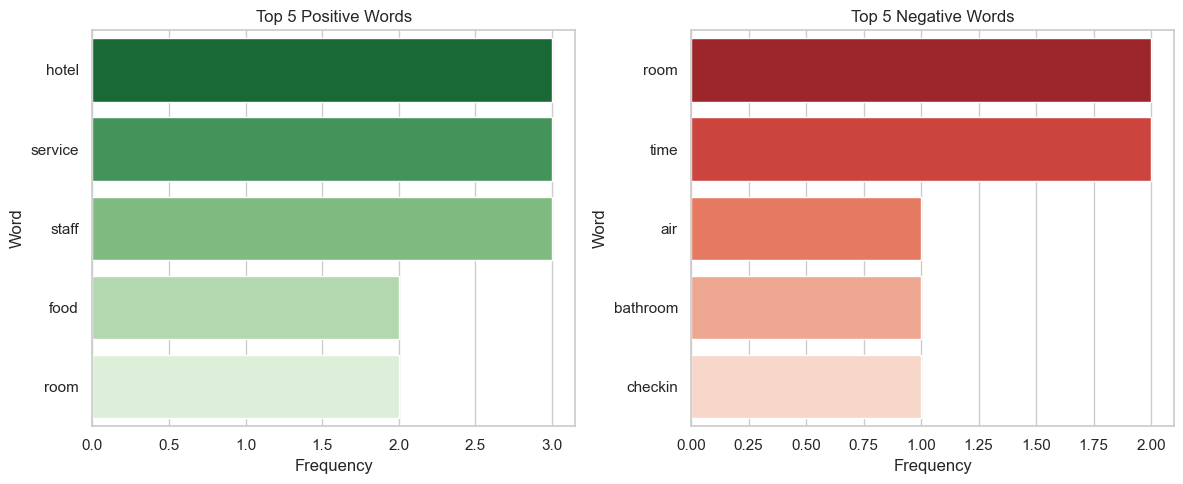

Top positive words


,word,frequency
2,hotel,3
15,service,3
3,staff,3
20,food,2
8,room,2


Top negative words


,word,frequency
7,room,2
5,time,2
29,air,1
10,bathroom,1
0,checkin,1


In [ ]:
def top_words_for_sentiment(df, sentiment, top_n=5):
    tokens = [token for row in df.loc[df["Sentiment"] == sentiment, "Tokens"] for token in row]
    return (
        pd.DataFrame(Counter(tokens).items(), columns=["word", "frequency"])
        .sort_values(["frequency", "word"], ascending=[False, True])
        .head(top_n)
    )


top_positive_words = top_words_for_sentiment(hotel_df, "positive")
top_negative_words = top_words_for_sentiment(hotel_df, "negative")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=top_positive_words, x="frequency", y="word", hue="word", palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Top 5 Positive Words")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

sns.barplot(data=top_negative_words, x="frequency", y="word", hue="word", palette="Reds_r", legend=False, ax=axes[1])
axes[1].set_title("Top 5 Negative Words")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab2_top_sentiment_words.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top positive words")
display(top_positive_words)
print("Top negative words")
display(top_negative_words)

**Interpretation:** Positive reviews emphasize service quality and comfort, while negative reviews highlight problems such as slow processes, cleanliness issues, poor responsiveness, and maintenance concerns.

## 8. Confusion Matrix Heatmap

The confusion matrix compares actual and predicted sentiment classes for the test set.

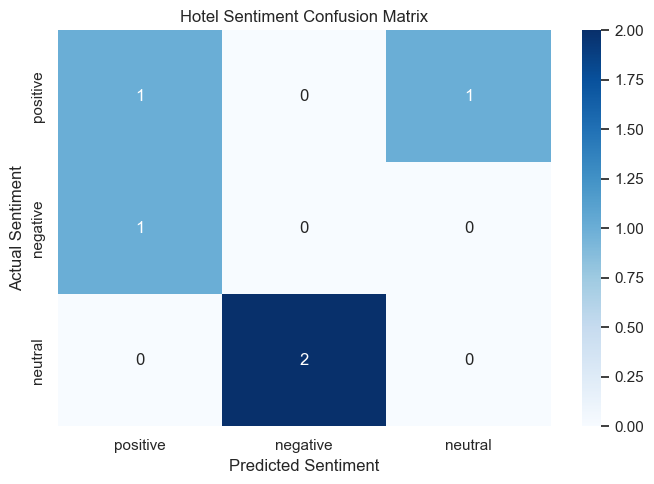

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    lab2_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["positive", "negative", "neutral"],
    yticklabels=["positive", "negative", "neutral"],
)
plt.title("Hotel Sentiment Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Correct predictions appear on the diagonal. Misclassifications show where the model confuses sentiments, which can happen because the dataset is small and some reviews contain overlapping hotel vocabulary.

## 9. Test the Model on a New Review

A new hotel review is cleaned, vectorized using the trained TF-IDF vectorizer, and classified with the trained Naive Bayes model.

In [ ]:
new_review = "The staff were very helpful and the room was clean"
new_review_cleaned = " ".join(preprocess_text(new_review))
new_review_vector = tfidf_vectorizer_lab2.transform([new_review_cleaned])
new_review_prediction = sentiment_model.predict(new_review_vector)[0]

print("New review:", new_review)
print("Cleaned review:", new_review_cleaned)
print("Predicted sentiment:", new_review_prediction)

New review: The staff were very helpful and the room was clean
Cleaned review: staff helpful room clean
Predicted sentiment: positive


# Final Summary

LAB_1 demonstrated that preprocessing makes short text easier to analyze by removing unhelpful words and punctuation. Frequency analysis and word clouds showed dominant terms such as education, technology, data, and learning. TF-IDF and bigram TF-IDF converted the cleaned text into numerical representations for analysis.

LAB_2 trained a Multinomial Naive Bayes sentiment classifier on hotel reviews. The model was evaluated using accuracy, a classification report, and a confusion matrix, and it predicted the new review as a positive sentiment because it contains favorable terms such as `helpful` and `clean`.

## Create README and Submission Report

The final cell writes the project README and report-ready markdown file using the computed notebook results.

In [ ]:
readme_text = f"""# Big Data Analytics and Visualization: NLP Lab Exercises

## Objective
Complete LAB_1 and LAB_2 using Python NLP techniques for text preprocessing, visualization, TF-IDF vectorization, and sentiment classification.

## Libraries Used
- pandas
- matplotlib
- seaborn
- nltk
- wordcloud
- scikit-learn

## How to Run the Notebook
1. Open `nlp_lab_exercises.ipynb` in Jupyter Notebook, JupyterLab, or VS Code.
2. Install dependencies if needed:
   ```bash
   pip install pandas matplotlib seaborn nltk wordcloud scikit-learn
   ```
3. Run all cells from top to bottom.
4. Generated CSV files and PNG plots will be saved in the project folder and `outputs/`.

## LAB_1 Summary
LAB_1 loads five text sentences, preprocesses them using lowercase conversion, punctuation removal, tokenization, stopword removal, and cleaned text construction. It then performs word frequency analysis, exports `word_frequency_lab1.csv`, creates bar charts and word clouds, and applies TF-IDF and bigram TF-IDF.

## LAB_2 Summary
LAB_2 loads 25 hotel reviews labeled as positive, negative, or neutral. It preprocesses the reviews, applies TF-IDF vectorization, trains a Multinomial Naive Bayes classifier, evaluates the model, exports `hotel_sentiment_results.csv`, and predicts sentiment for a new review.

## Key Findings
- LAB_1 dominant terms include `{', '.join(top5_lab1['word'].tolist())}`.
- Adding extra LAB_1 sentences increases the importance of repeated topic words such as data, education, technology, and learning.
- Positive hotel reviews frequently mention service, staff, cleanliness, comfort, and food quality.
- Negative reviews focus on slow service, cleanliness issues, noise, responsiveness, and maintenance problems.

## Model Performance Summary
The Multinomial Naive Bayes classifier achieved an accuracy of `{lab2_accuracy:.2f}` on the test split. Because the dataset is small, the results should be interpreted as a lab demonstration rather than a production-level performance estimate.
"""

report_text = f"""# Big Data Analytics and Visualization: NLP Lab Exercises Report

## Introduction
This report presents two Natural Language Processing lab exercises completed in Python. The first lab focuses on text preprocessing, word frequency analysis, visualization, and TF-IDF representation. The second lab applies the same preprocessing ideas to hotel review sentiment analysis using a supervised machine learning classifier.

## Objectives
- Load text datasets into pandas DataFrames.
- Clean and tokenize text using NLTK.
- Remove punctuation, stopwords, and non-alphabetic tokens.
- Create word frequency tables, bar charts, word clouds, and word length plots.
- Apply TF-IDF and bigram TF-IDF vectorization.
- Train and evaluate a Multinomial Naive Bayes sentiment classifier.
- Export analysis results and visualizations for submission.

## Tools and Libraries
The project uses Python in a Jupyter Notebook with pandas for data handling, matplotlib and seaborn for plotting, NLTK for tokenization and stopwords, wordcloud for word cloud visualization, and scikit-learn for TF-IDF vectorization, train-test splitting, Naive Bayes modeling, and evaluation metrics.

## LAB_1 Methodology
The LAB_1 text dataset was loaded into a pandas DataFrame. Text was converted to lowercase, punctuation was removed, words were tokenized with NLTK, English stopwords were removed, and cleaned text strings were created from the remaining tokens. Word frequencies were calculated using `Counter`. The analysis then produced a top-five word bar chart, word cloud, and word length distribution plot. TF-IDF was applied to the cleaned text, followed by bigram TF-IDF using `TfidfVectorizer(ngram_range=(1, 2))`. Extra sentences were added to observe how word frequencies and word clouds changed. Additional manual stopwords such as `data`, `fields`, and `related` were also removed.

## LAB_1 Results and Interpretation
The original LAB_1 word frequency table was exported as `word_frequency_lab1.csv`. The most frequent words were `{', '.join(top5_lab1['word'].tolist())}`. These terms show that the corpus is mainly about education, technology, data, and machine learning. The word cloud visually confirmed the same pattern. The word length distribution showed that many words were medium-length content words, which is expected after stopword removal. TF-IDF produced a numerical matrix showing the importance of each term in each sentence, while bigram TF-IDF captured meaningful phrases such as machine learning, data science, and decision making.

## LAB_2 Methodology
The hotel review dataset was loaded into a DataFrame with `Text` and `Sentiment` columns. The sentiment distribution was visualized to inspect class balance. Reviews were lowercased, tokenized, stripped of punctuation, filtered to alphabetic tokens, and cleaned of stopwords. The cleaned text was transformed using TF-IDF. The dataset was split into training and testing sets using `test_size=0.2` and `random_state=42`. A Multinomial Naive Bayes classifier was trained and evaluated on the test set.

## LAB_2 Results and Interpretation
The classifier achieved an accuracy of `{lab2_accuracy:.2f}` on the test set. The classification report and confusion matrix were generated in the notebook. Test results were exported as `hotel_sentiment_results.csv`. The sentiment distribution was nearly balanced, supporting fairer model training. The top positive words reflected favorable service and comfort themes, while top negative words reflected problems with service, cleanliness, noise, and maintenance. The new review, `The staff were very helpful and the room was clean`, was predicted as `{new_review_prediction}`.

## Discussion
The labs show the importance of preprocessing before analysis or machine learning. Removing stopwords and punctuation makes vocabulary patterns easier to interpret. Frequency analysis and word clouds are useful for quick exploration, while TF-IDF provides a more structured numerical representation. In LAB_2, Naive Bayes was suitable for the small text classification task and produced understandable results.

## Limitations
The datasets are small, so the findings may not generalize to larger or more diverse text collections. The train-test split in LAB_2 contains only five test reviews, so accuracy can change substantially with a different split. The model also uses a bag-of-words style representation, meaning it does not deeply understand context, sarcasm, or complex sentiment expressions.

## Conclusion
Both labs were completed successfully. LAB_1 demonstrated text cleaning, frequency analysis, visualizations, and TF-IDF features. LAB_2 demonstrated a complete sentiment analysis workflow from data loading to preprocessing, model training, evaluation, visualization, result export, and prediction on a new review.

## References
- Bird, S., Klein, E., & Loper, E. (2009). Natural Language Processing with Python.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python.
- pandas documentation: https://pandas.pydata.org/
- Matplotlib documentation: https://matplotlib.org/
- seaborn documentation: https://seaborn.pydata.org/
- wordcloud documentation: https://amueller.github.io/word_cloud/
"""

Path("README.md").write_text(readme_text.replace("        ", ""), encoding="utf-8")
Path("submission_report.md").write_text(report_text.replace("        ", ""), encoding="utf-8")

print("Created README.md and submission_report.md")

Created README.md and submission_report.md
